The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.

Convergence Study
-----------------

RK4 errors:
dt = 0.10000, error = 2.240348e-02
dt = 0.05000, error = 8.288497e-04
dt = 0.02500, error = 1.260951e-04
dt = 0.01250, error = 4.363293e-05
dt = 0.00625, error = 1.347848e-05

Euler errors:
dt = 0.10000, error = 7.827559e-01
dt = 0.05000, error = 2.169987e-01
dt = 0.02500, error = 9.207973e-02
dt = 0.01250, error = 4.310520e-02
dt = 0.00625, error = 2.090515e-02

Observed RK4 convergence orders:
[4.756468728470419, 2.716598347504271, 1.5310230102405729, 1.6947589787868496]

Observed Euler convergence orders:
[1.8508759563689885, 1.2367309903050334, 1.0950215236298613, 1.0440036132863133]
the error for RK4 is smaller in general, this is a more accurate method


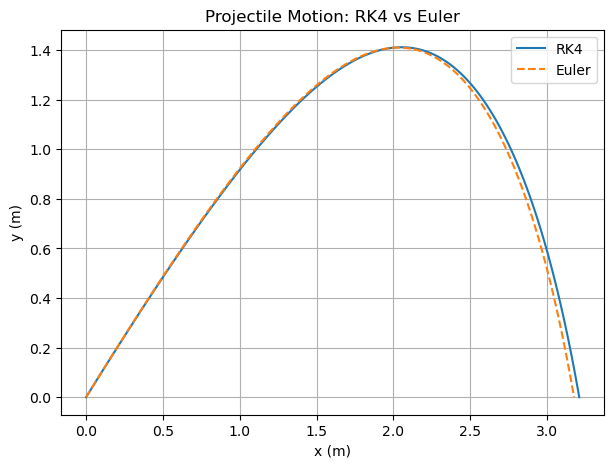

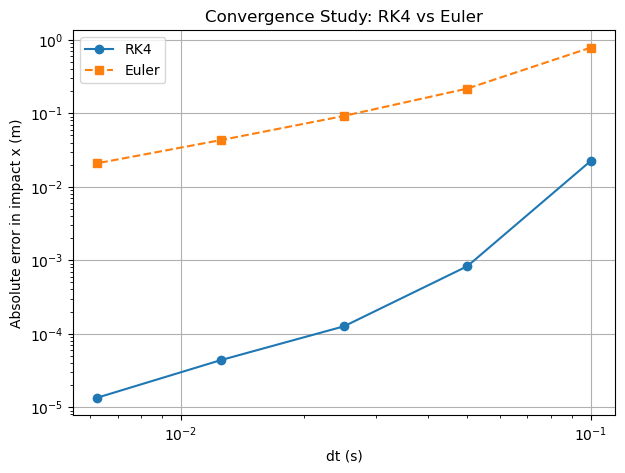

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar
from scipy.integrate import solve_ivp

# ============================================================
# 1. PHYSICS MODELS
# ============================================================

def projectile_ode(t, y, k, m, g):
    """
    Projectile motion with quadratic air resistance.

    State vector:
        y = [x, y, vx, vy]

    Parameters:
        k = drag coefficient
        m = mass
        g = gravitational acceleration
    """

    x, y_pos, vx, vy = y

    # Magnitude of velocity
    speed = np.sqrt(vx**2 + vy**2)

    # Position derivatives
    dxdt = vx
    dydt = vy

    # Acceleration due to quadratic drag
    dvxdt = -(k / m) * speed * vx
    dvydt = -g - (k / m) * speed * vy

    return np.array([dxdt, dydt, dvxdt, dvydt])


def projectile_ode_altitude(t, y, k0, H, m, g):
    """
    Projectile motion with quadratic drag that decreases
    exponentially with altitude.

    k(y) = k0 * exp(-y/H)

    Parameters:
        k0 = drag coefficient at ground level
        H  = characteristic height
        m  = mass
        g  = gravitational acceleration
    """

    x, y_pos, vx, vy = y

    # Drag coefficient decreases with altitude
    k = k0 * np.exp(-y_pos / H)

    # Magnitude of velocity
    speed = np.sqrt(vx**2 + vy**2)

    # Position derivatives
    dxdt = vx
    dydt = vy

    # Acceleration
    dvxdt = -(k / m) * speed * vx
    dvydt = -g - (k / m) * speed * vy

    return np.array([dxdt, dydt, dvxdt, dvydt])
# ============================================================
# 2. RK4 NUMERICAL SOLVER
# ============================================================

def rk4_step(f, t, y, dt, *args):
    """
    Perform one fourth-order Runge-Kutta (RK4) timestep.
    """

    k1 = f(t, y, *args)

    k2 = f(
        t + dt / 2,
        y + (dt / 2) * k1,
        *args
    )

    k3 = f(
        t + dt / 2,
        y + (dt / 2) * k2,
        *args
    )

    k4 = f(
        t + dt,
        y + dt * k3,
        *args
    )

    return y + (dt / 6) * (
        k1 + 2*k2 + 2*k3 + k4
    )


# ============================================================
# 3. EULER NUMERICAL SOLVER
# ============================================================

def euler_step(f, t, y, dt, *args):
    """
    Perform one Euler timestep.
    """

    return y + dt * f(t, y, *args)


# ============================================================
# 4. TRAJECTORY SIMULATOR
# ============================================================

def simulate_trajectory(
    f,
    y0,
    dt,
    t_max,
    *args,
    method='RK4'
):
    """
    Simulate projectile trajectory using either RK4 or Euler.

    The simulation stops when the projectile reaches the ground.

    Ground impact is estimated using linear interpolation between
    the last point above the ground and the first point below it.

    Returns:
        Array containing [x, y, vx, vy] at each timestep.
    """

    # Number of numerical steps
    num_steps = int(t_max / dt)

    # Storage for trajectory
    traj = np.zeros((num_steps + 1, 4))

    # Store initial condition
    traj[0] = y0.copy()

    # Current state
    y = y0.copy()

    # Current time
    t = 0.0

    # Perform simulation
    for i in range(num_steps):

        # Store previous state before taking the step
        y_previous = y.copy()

        # ----------------------------------------------------
        # Take one numerical step
        # ----------------------------------------------------

        if method.upper() == 'RK4':

            y = rk4_step(
                f,
                t,
                y,
                dt,
                *args
            )

        elif method.upper() == 'EULER':

            y = euler_step(
                f,
                t,
                y,
                dt,
                *args
            )

        else:

            raise ValueError(
                "Method must be 'RK4' or 'Euler'"
            )

        # Advance time
        t += dt

        # ----------------------------------------------------
        # Check for ground impact
        # ----------------------------------------------------

        if y[1] < 0:

            # Fraction of the timestep at which y = 0
            fraction = (
                y_previous[1]
                / (y_previous[1] - y[1])
            )

            # Interpolate the complete state
            y_impact = (
                y_previous
                + fraction * (y - y_previous)
            )

            # Force vertical position to exactly zero
            y_impact[1] = 0.0

            # Store impact state
            traj[i + 1] = y_impact

            # Return only the trajectory up to impact
            return traj[:i + 2]

        # Store normal timestep
        traj[i + 1] = y

    return traj


# ============================================================
# 5. GENERAL SIMULATION FUNCTION
# ============================================================

def run_simulation(
    m=0.2,
    k=0.1,
    g=9.81,
    y0=None,
    dt=0.01,
    t_max=2.0,
    method='RK4',
    altitude=False,
    H=10.0
):
    """
    General simulation function.

    Allows the user to switch between:
        - RK4 / Euler
        - constant drag / altitude-dependent drag
    """

    # Default initial conditions
    if y0 is None:
        y0 = np.array([
            0.0,   # x position
            0.0,   # y position
            10.0,  # horizontal velocity
            10.0   # vertical velocity
        ])

    # Select physical model
    if altitude:

        traj = simulate_trajectory(
            projectile_ode_altitude,
            y0,
            dt,
            t_max,
            k,
            H,
            m,
            g,
            method=method
        )

    else:

        traj = simulate_trajectory(
            projectile_ode,
            y0,
            dt,
            t_max,
            k,
            m,
            g,
            method=method
        )

    return traj



# ============================================================
# 6. HIGH-ACCURACY REFERENCE SOLUTION
# ============================================================

def reference_solution(
    y0,
    t_max,
    m,
    k,
    g
):
    """
    Calculate a high-accuracy reference solution using SciPy's
    solve_ivp.

    This is the reference solution used to calculate numerical errors
    in the convergence study.
    """

    # Define the ODE for solve_ivp
    def ode(t, y):
        return projectile_ode(
            t,
            y,
            k,
            m,
            g
        )

    # Ground-impact event
    def hit_ground(t, y):
        return y[1]

    # Tell solve_ivp to stop at the event
    hit_ground.terminal = True

    # Only detect downward crossings
    hit_ground.direction = -1

    # Solve with high accuracy
    sol = solve_ivp(
        ode,
        [0, t_max],
        y0,
        rtol=1e-10,
        atol=1e-12,
        events=hit_ground,
        max_step=0.001
    )

    # Extract horizontal position at impact
    x_impact = sol.y_events[0][0][0]

    return x_impact


# ============================================================
# 7. CONVERGENCE STUDY
# ============================================================

def convergence_test(
    y0,
    t_max,
    dt_values,
    m,
    k,
    g,
    method='RK4',
    altitude=False,
    H=10.0
):
    """
    Calculate numerical errors for a range of timesteps.

    Error is calculated relative to a high-accuracy reference
    solution.
    """

    # Calculate reference solution
    reference_x = reference_solution(
        y0,
        t_max,
        m,
        k,
        g
    )

    errors = []

    # Test each timestep
    for dt in dt_values:

        traj = run_simulation(
            m=m,
            k=k,
            g=g,
            y0=y0,
            dt=dt,
            t_max=t_max,
            method=method,
            altitude=altitude,
            H=H
        )

        # Numerical impact position
        numerical_x = traj[-1, 0]

        # Absolute error
        error = abs(
            numerical_x - reference_x
        )

        errors.append(error)

    return errors


# ============================================================
# 8. CALCULATE OBSERVED CONVERGENCE ORDER
# ============================================================

def calculate_order(dt_values, errors):
    """
    Calculate observed order of convergence.

    For:
        error ~ dt^p

    the convergence order is:

        p = log(E1/E2) / log(dt1/dt2)
    """

    orders = []

    for i in range(len(errors) - 1):

        p = (
            np.log(errors[i] / errors[i + 1])
            /
            np.log(dt_values[i] / dt_values[i + 1])
        )

        orders.append(p)

    return orders
# ============================================================
# 11. MAIN PROGRAM
# ============================================================

if __name__ == "__main__":

    # --------------------------------------------------------
    # Default parameters
    # --------------------------------------------------------

    y0 = np.array([
        0.0,
        0.0,
        10.0,
        10.0
    ])

    dt = 0.01
    t_max = 2.0

    m = 0.2
    k = 0.1
    g = 9.81

    # ========================================================
    # A. RK4 VS EULER 
    # ========================================================

    traj_rk4 = run_simulation(
        m=m,
        k=k,
        g=g,
        y0=y0,
        dt=dt,
        t_max=t_max,
        method='RK4'
    )

    traj_euler = run_simulation(
        m=m,
        k=k,
        g=g,
        y0=y0,
        dt=dt,
        t_max=t_max,
        method='Euler'
    )
    
    plt.figure(figsize=(7, 5))

    plt.plot(
        traj_rk4[:, 0],
        traj_rk4[:, 1],
        label='RK4'
    )

    plt.plot(
        traj_euler[:, 0],
        traj_euler[:, 1],
        label='Euler',
        linestyle='--'
    )

    plt.xlabel('x (m)')
    plt.ylabel('y (m)')
    plt.title('Projectile Motion: RK4 vs Euler')

    plt.legend()
    plt.grid()

    
    
    # ========================================================
    # B. CONVERGENCE STUDY
    # ========================================================

    dt_values = [
        0.1,
        0.05,
        0.025,
        0.0125,
        0.00625
    ]

    errors_rk4 = convergence_test(
        y0,
        t_max,
        dt_values,
        m=m,
        k=k,
        g=g,
        method='RK4'
    )

    errors_euler = convergence_test(
        y0,
        t_max,
        dt_values,
        m=m,
        k=k,
        g=g,
        method='Euler'
    )

    # Calculate observed orders
    rk4_orders = calculate_order(
        dt_values,
        errors_rk4
    )

    euler_orders = calculate_order(
        dt_values,
        errors_euler
    )

    # Print results
    print("\nConvergence Study")
    print("-----------------")

    print("\nRK4 errors:")
    for dt_val, error in zip(
        dt_values,
        errors_rk4
    ):
        print(
            f"dt = {dt_val:.5f}, "
            f"error = {error:.6e}"
        )

    print("\nEuler errors:")
    for dt_val, error in zip(
        dt_values,
        errors_euler
    ):
        print(
            f"dt = {dt_val:.5f}, "
            f"error = {error:.6e}"
        )

    print("\nObserved RK4 convergence orders:")
    print(rk4_orders)

    print("\nObserved Euler convergence orders:")
    print(euler_orders)

    print("the error for RK4 is smaller in general, this is a more accurate method")

    # Plot convergence
    plt.figure(figsize=(7, 5))

    plt.loglog(
        dt_values,
        errors_rk4,
        'o-',
        label='RK4'
    )

    plt.loglog(
        dt_values,
        errors_euler,
        's--',
        label='Euler'
    )

    plt.xlabel('dt (s)')
    plt.ylabel(
        'Absolute error in impact x (m)'
    )

    plt.title(
        'Convergence Study: RK4 vs Euler'
    )

    plt.legend()
    plt.grid()


 
plt.show()